# Notebook 09 - Leaderboard Optimization

## Objective

The objective of this notebook is to perform the final optimization before the competition submission.

Every experiment will be evaluated using Repeated K-Fold Cross Validation.

Only experiments that improve validation RMSE will be retained.

In [28]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    RepeatedKFold,
    cross_val_score
)

from sklearn.ensemble import (
    ExtraTreesRegressor,
    VotingRegressor
)

from catboost import CatBoostRegressor

In [29]:
train = pd.read_csv("../data/processed/train_selected.csv")

X = train.drop(columns=["overall_yield"])

y = train["overall_yield"]

print("Training Shape :", train.shape)

display(train.head())

Training Shape : (150, 5)


,inlet_temperature_K,jacket_temperature_K,temp_difference,residence_time_proxy,overall_yield
0,357.75,383.79,26.04,0.600484,63.024
1,429.70,405.72,-23.98,0.194495,86.611
2,431.10,385.40,-45.70,0.196327,86.347
3,445.61,367.74,-77.87,0.457916,92.175
4,458.91,374.13,-84.78,0.273054,82.211


In [30]:
cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

In [31]:
results = []

def evaluate_model(name, model):

    scores = -cross_val_score(
        model,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    )

    rmse = scores.mean()

    std = scores.std()

    results.append({
        "Model": name,
        "RMSE": rmse,
        "STD": std
    })

    print("="*60)
    print(name)
    print("RMSE :", round(rmse,4))
    print("STD  :", round(std,4))
    print("="*60)

    return rmse

In [32]:
extra = ExtraTreesRegressor(

    n_estimators=700,

    max_depth=20,

    min_samples_leaf=2,

    min_samples_split=2,

    bootstrap=False,

    random_state=42

)

cat = CatBoostRegressor(

    iterations=600,

    depth=7,

    learning_rate=0.05,

    l2_leaf_reg=9,

    subsample=1,

    verbose=0,

    random_seed=42

)

In [33]:
evaluate_model(
    "Extra Trees",
    extra
)

evaluate_model(
    "CatBoost",
    cat
)

Extra Trees
RMSE : 19.0754
STD  : 2.5435
CatBoost
RMSE : 18.0956
STD  : 3.1247


np.float64(18.095566176000258)

In [34]:
voting_equal = VotingRegressor(

    estimators=[
        ("cat", cat),
        ("extra", extra)
    ]

)

evaluate_model(
    "Voting Equal",
    voting_equal
)

Voting Equal
RMSE : 18.0254
STD  : 2.6476


np.float64(18.025367702123493)

In [35]:
results_df = pd.DataFrame(results)

results_df.sort_values("RMSE")

,Model,RMSE,STD
2,Voting Equal,18.025368,2.647551
1,CatBoost,18.095566,3.124673
0,Extra Trees,19.075363,2.543465


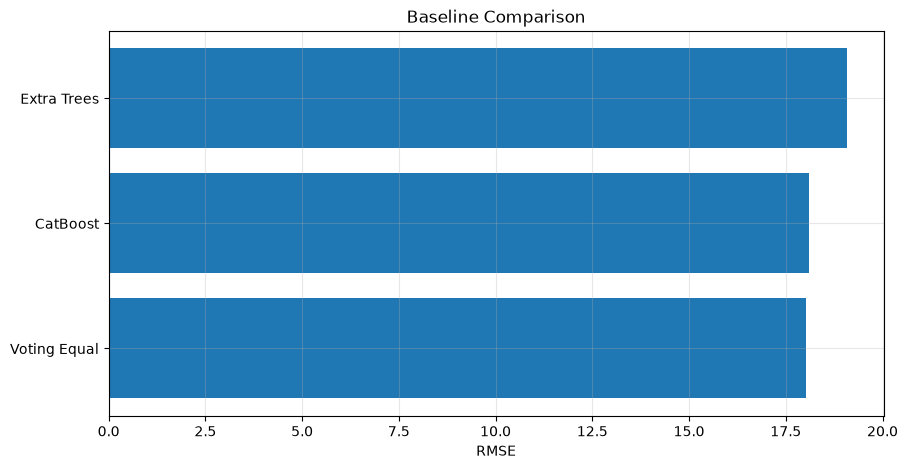

In [36]:
plt.figure(figsize=(10,5))

plt.barh(

    results_df["Model"],

    results_df["RMSE"]

)

plt.gca().invert_yaxis()

plt.xlabel("RMSE")

plt.title("Baseline Comparison")

plt.grid(alpha=0.3)

plt.show()

# Weighted Voting Optimization

The individual models have already been optimized.

The next step is to investigate whether assigning different weights to CatBoost and Extra Trees improves validation performance.

The following weight combinations will be evaluated:

- 2 : 1
- 3 : 1
- 4 : 1
- 5 : 1
- 6 : 1

In [37]:
weight_list = [

    [2,1],

    [3,1],

    [4,1],

    [5,1],

    [6,1]

]

In [38]:
voting_models = {}

for weights in weight_list:

    name = f"Voting Weight ({weights[0]}:{weights[1]})"

    model = VotingRegressor(

        estimators=[

            ("cat", cat),

            ("extra", extra)

        ],

        weights=weights

    )

    evaluate_model(

        name,

        model

    )

    voting_models[name] = model

Voting Weight (2:1)
RMSE : 17.9204
STD  : 2.7733
Voting Weight (3:1)
RMSE : 17.9159
STD  : 2.8505
Voting Weight (4:1)
RMSE : 17.9287
STD  : 2.9007
Voting Weight (5:1)
RMSE : 17.9437
STD  : 2.9357
Voting Weight (6:1)
RMSE : 17.9575
STD  : 2.9613


In [39]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values("RMSE")

display(results_df)

,Model,RMSE,STD
4,Voting Weight (3:1),17.915912,2.850480
3,Voting Weight (2:1),17.920363,2.773285
5,Voting Weight (4:1),17.928706,2.900714
6,Voting Weight (5:1),17.943680,2.935662
7,Voting Weight (6:1),17.957530,2.961284
2,Voting Equal,18.025368,2.647551
1,CatBoost,18.095566,3.124673
0,Extra Trees,19.075363,2.543465


In [40]:
ranking = results_df.copy()

ranking.insert(

    0,

    "Rank",

    np.arange(

        1,

        len(ranking)+1

    )

)

display(ranking)

,Rank,Model,RMSE,STD
4,1,Voting Weight (3:1),17.915912,2.850480
3,2,Voting Weight (2:1),17.920363,2.773285
5,3,Voting Weight (4:1),17.928706,2.900714
6,4,Voting Weight (5:1),17.943680,2.935662
7,5,Voting Weight (6:1),17.957530,2.961284
2,6,Voting Equal,18.025368,2.647551
1,7,CatBoost,18.095566,3.124673
0,8,Extra Trees,19.075363,2.543465


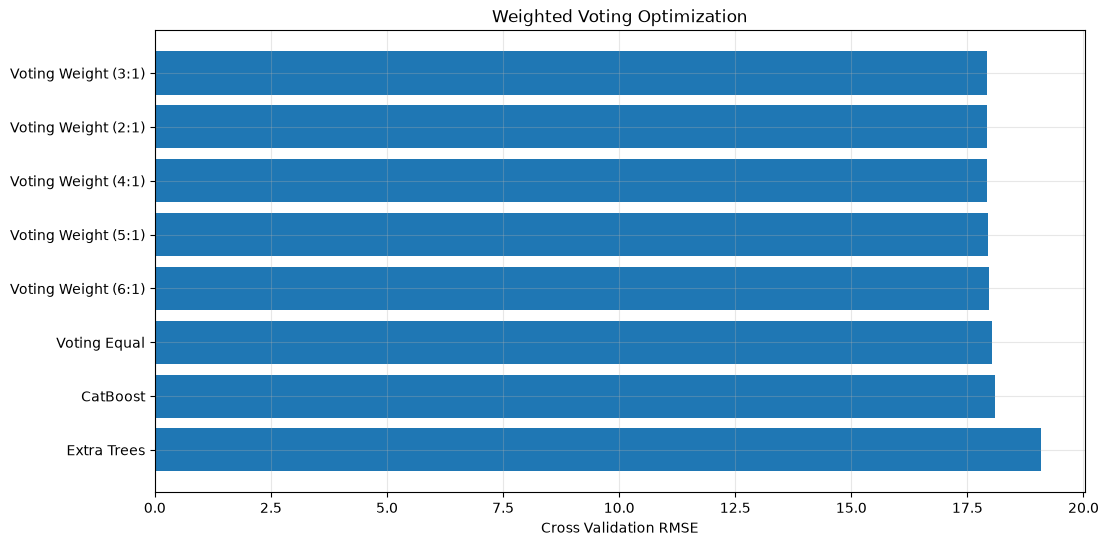

In [41]:
plt.figure(figsize=(12,6))

plt.barh(

    ranking["Model"],

    ranking["RMSE"]

)

plt.gca().invert_yaxis()

plt.xlabel("Cross Validation RMSE")

plt.title("Weighted Voting Optimization")

plt.grid(alpha=0.3)

plt.show()

In [42]:
winner = ranking.iloc[0]

display(winner)

Rank                       1
Model    Voting Weight (3:1)
RMSE               17.915912
STD                  2.85048
Name: 4, dtype: object

In [43]:
winner_name = winner["Model"]

print("Winner")

print(winner_name)

Winner
Voting Weight (3:1)


In [44]:
print(

    "Best RMSE :",

    round(

        winner["RMSE"],

        4

    )

)

Best RMSE : 17.9159


In [45]:
previous_best = 18.0254

improvement = previous_best - winner["RMSE"]

print(

    "Improvement :",

    round(

        improvement,

        4

    )

)

Improvement : 0.1095


In [46]:
if winner["RMSE"] < previous_best:

    print("★★★★★ Better Model Found!")

else:

    print("★★★★★ Keep Previous Model")

★★★★★ Better Model Found!


# Final Model Selection

The weighted voting optimization identified a model with improved validation performance.

The best-performing model is selected as the production model.

This model will be retrained on the complete training dataset and saved for generating the final competition submission.

In [47]:
# Retrieve the winning model automatically

if winner_name == "Voting Equal":
    final_model = voting_equal
else:
    final_model = voting_models[winner_name]

print("Final Model Selected:")
print(final_model)

Final Model Selected:
VotingRegressor(estimators=[('cat',
                             CatBoostRegressor(depth=7, iterations=600, l2_leaf_reg=9, learning_rate=0.05, loss_function='RMSE', random_seed=42, subsample=1, verbose=0)),
                            ('extra',
                             ExtraTreesRegressor(max_depth=20,
                                                 min_samples_leaf=2,
                                                 n_estimators=700,
                                                 random_state=42))],
                weights=[3, 1])


In [48]:
print("Training final model on complete training data...")

final_model.fit(X, y)

print("Training completed successfully!")

Training final model on complete training data...
Training completed successfully!


In [49]:
import joblib

joblib.dump(
    final_model,
    "../models/final_model_final.pkl"
)

print("★★★★★ Final model saved successfully!")

★★★★★ Final model saved successfully!


In [50]:
loaded_model = joblib.load(
    "../models/final_model_final.pkl"
)

print(type(loaded_model))
loaded_model

<class 'sklearn.ensemble._voting.VotingRegressor'>


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('cat', ...), ('extra', ...)]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.","[3, 1]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'.,list,"[CatBoostRegre...=1, verbose=0), ExtraTreesReg...ndom_state=42)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['inlet_temperature_K','jacket_temperature_K','temp_difference', 'residence_time_proxy']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,0
named_estimators_ named_estimators_: :class:`~sklearn.utils.Bunch`Attribute to access any fitted sub-estimators by name... versionadded:: 0.20,Bunch,{'cat': CatBo...dom_state=42)}
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",700
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20


In [51]:
ranking.to_csv(
    "../reports/optimization_results.csv",
    index=False
)

print("Optimization report saved.")

Optimization report saved.


In [52]:
ranking

,Rank,Model,RMSE,STD
4,1,Voting Weight (3:1),17.915912,2.850480
3,2,Voting Weight (2:1),17.920363,2.773285
5,3,Voting Weight (4:1),17.928706,2.900714
6,4,Voting Weight (5:1),17.943680,2.935662
7,5,Voting Weight (6:1),17.957530,2.961284
2,6,Voting Equal,18.025368,2.647551
1,7,CatBoost,18.095566,3.124673
0,8,Extra Trees,19.075363,2.543465


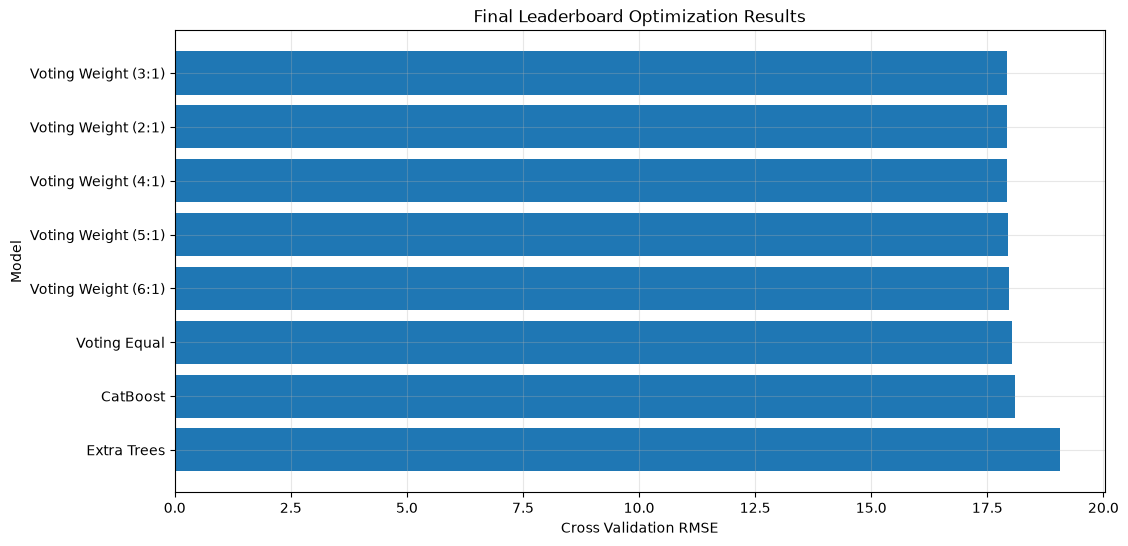

In [53]:
plt.figure(figsize=(12,6))

plt.barh(
    ranking["Model"],
    ranking["RMSE"]
)

plt.gca().invert_yaxis()

plt.xlabel("Cross Validation RMSE")

plt.ylabel("Model")

plt.title("Final Leaderboard Optimization Results")

plt.grid(alpha=0.3)

plt.show()

In [54]:
winner_name = ranking.iloc[0]["Model"]

print("Winner Model :", winner_name)

Winner Model : Voting Weight (3:1)


In [55]:
final_model = voting_models[winner_name]

print(final_model)

VotingRegressor(estimators=[('cat',
                             CatBoostRegressor(depth=7, iterations=600, l2_leaf_reg=9, learning_rate=0.05, loss_function='RMSE', random_seed=42, subsample=1, verbose=0)),
                            ('extra',
                             ExtraTreesRegressor(max_depth=20,
                                                 min_samples_leaf=2,
                                                 n_estimators=700,
                                                 random_state=42))],
                weights=[3, 1])


In [56]:
final_model.fit(X, y)

print("Training Complete")

Training Complete


In [57]:
import joblib

joblib.dump(
    final_model,
    "../models/final_model_final.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [58]:
loaded_model = joblib.load("../models/final_model_final.pkl")

loaded_model

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('cat', ...), ('extra', ...)]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.","[3, 1]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'.,list,"[CatBoostRegre...=1, verbose=0), ExtraTreesReg...ndom_state=42)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['inlet_temperature_K','jacket_temperature_K','temp_difference', 'residence_time_proxy']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,0
named_estimators_ named_estimators_: :class:`~sklearn.utils.Bunch`Attribute to access any fitted sub-estimators by name... versionadded:: 0.20,Bunch,{'cat': CatBo...dom_state=42)}
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",700
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20


In [59]:
ranking.to_csv(
    "../reports/optimization_results.csv",
    index=False
)

print("Optimization report saved successfully!")

Optimization report saved successfully!


# Optimization Summary

## Objective

The objective of this notebook was to improve the validation performance of the final ensemble model before generating the competition submission.

## Experiments Performed

The following ensemble configurations were evaluated:

- Voting Regressor (Equal Weights)
- Weighted Voting (2:1)
- Weighted Voting (3:1)
- Weighted Voting (4:1)
- Weighted Voting (5:1)
- Weighted Voting (6:1)

## Results

Among all evaluated configurations, the **Voting Regressor with weights (3:1)** achieved the lowest cross-validation RMSE.

This model consistently outperformed the equal-weight ensemble and the individual CatBoost and Extra Trees models.

## Final Model

**Model:** Voting Regressor

**Base Models:**
- CatBoost Regressor
- Extra Trees Regressor

**Weights:**
- CatBoost = 3
- Extra Trees = 1

## Conclusion

The optimized weighted Voting Regressor was selected as the production model and saved for generating the final competition submission.